<p style="text-align: center; font-size: 28px;"><b>Predict Baseball Strike Zones With Machine Learning</b></p>

summary

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from utilities.svm_visualization import draw_boundary

# Create the labels

<p style="font-size: 20px;"><b>Task 1</b></p>  
We’ve imported several DataFrames related to some of baseball’s biggest stars. We have data on Aaron Judge and Jose Altuve. Judge is one of the tallest players in the league and Altuve is one of the shortest. Their strike zones should be pretty different!  

Each row in these DataFrames corresponds to a single pitch that the batter saw in the 2017 season. To begin, take a look at all of the features of a pitch by printing:
`print(aaron_judge.columns)`

In this project, you’ll print out a lot of information. To avoid clutter, feel free to delete the print statements once you understand the data.

We used the **pybaseball** Python package to get the data for this project. If you’re interested in exploring more data, the documentation for pybaseball can help you get data that you’re interested in onto your own computer.


In [2]:
aaron_judge = pd.read_csv("utilities/aaron_judge.csv")
jose_altruve = pd.read_csv("utilities/jose_altruve.csv")
david_ortiz = pd.read_csv("utilities/david_ortiz.csv")

In [3]:
print(aaron_judge.columns)

Index(['pitch_type', 'game_date', 'release_speed', 'release_pos_x',
       'release_pos_z', 'player_name', 'batter', 'pitcher', 'events',
       'description', 'spin_dir', 'spin_rate_deprecated',
       'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des',
       'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type',
       'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'pfx_x',
       'pfx_z', 'plate_x', 'plate_z', 'on_3b', 'on_2b', 'on_1b',
       'outs_when_up', 'inning', 'inning_topbot', 'hc_x', 'hc_y',
       'tfs_deprecated', 'tfs_zulu_deprecated', 'pos2_person_id', 'umpire',
       'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot',
       'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed',
       'release_spin_rate', 'release_extension', 'game_pk', 'pos1_person_id',
       'pos2_person_id.1', 'pos3_person_id', 'pos4_person_id',
       'pos5_person_id', 'pos6_person_id', 'pos7_person_id', 'pos8_person_id',

<p style="font-size: 20px;"><b>Task 2</b></p>  
Some of these features have obscure names. Let’s learn what the feature `description` means.  

Print the unique values of this feature to see the different pitch outcomes by running:
`print(aaron_judge.description.unique())`

In [4]:
print(aaron_judge.description.unique())

['swinging_strike' 'called_strike' 'ball' 'hit_into_play_score' 'foul'
 'blocked_ball' 'hit_into_play' 'hit_into_play_no_out'
 'swinging_strike_blocked' 'foul_tip' 'hit_by_pitch']


<p style="font-size: 20px;"><b>Task 3</b></p>  
We’re interested in determining whether a pitch was a ball or a strike. This information is stored in the `type` feature.  

Examine the unique values in this feature to understand how balls and strikes are recorded by running:
`print(aaron_judge.type.unique())`

In [5]:
print(aaron_judge.type.unique())

['S' 'B' 'X']


<p style="font-size: 20px;"><b>Task 4</b></p>  
Great! We know that every row’s `type` feature is either an `'S'` for a strike, a `'B'` for a ball, or an `'X'` for neither (for example, an `'X'` could represent a hit or an out).  

We’ll use this feature as the label of our data points. However, instead of using strings, it will be easier if we change every `'S'` to a 1 and every `'B'` to a 0.

You can change the values of a DataFrame column using the `map()` function. For example, in the code below, every `'A'` in `example_column` is changed to a 1, and every `'B'` is changed to a 2.

In [6]:
print(aaron_judge['type'].head())

0    S
1    S
2    S
3    B
4    S
Name: type, dtype: object


In [7]:
aaron_judge['type'] = aaron_judge['type'].map({'S': 1, 'B': 0})
jose_altruve['type'] = jose_altruve['type'].map({'S':1, 'B':0})
david_ortiz['type'] = david_ortiz['type'].map({'S':1, 'B':0})

<p style="font-size: 20px;"><b>Task 5</b></p>  
Let’s make sure that the value mapping worked correctly.  

Print the `type` column from the `aaron_judge` DataFrame to verify the changes.

In [8]:
print(aaron_judge.type.unique())

[ 1.  0. nan]


# Plotting the pitches

<p style="font-size: 20px;"><b>Task 6</b></p>  
There were some NaNs in there. We’ll take care of those in a second. For now, let’s look at the other features we’re interested in.

We want to predict whether a pitch is a ball or a strike based on its location over the plate. You can find the ball’s location in the columns plate_x and plate_z.

Print aaron_judge['plate_x'] to see what that column looks like.

plate_x measures how far left or right the pitch is from the center of home plate. If plate_x = 0, that means the pitch was directly in the middle of the home plate.

In [9]:
print(aaron_judge['plate_x'])

0       1.0150
1       0.4546
2       0.0957
3       1.5161
4       0.0764
         ...  
2984   -0.3738
2985   -0.2953
2986    1.4094
2987    1.6717
2988   -0.1571
Name: plate_x, Length: 2989, dtype: float64


<p style="font-size: 20px;"><b>Task 7</b></p>  
We now have the three columns we want to work with: 'plate_x', 'plate_z', and 'type'.

Let’s remove every row that has a NaN in any of those columns.

You can do this by calling the dropna function. This function can take a parameter named subset which should be a list of the columns you’re interested in.

For example, the following code drops all of the NaN values from the columns 'A', 'B', and 'C'.

In [10]:
aaron_judge = aaron_judge.dropna(subset = ['plate_x', 'plate_z', 'type'])
jose_altruve = jose_altruve.dropna(subset = ['plate_x', 'plate_z', 'type'])
david_ortiz = david_ortiz.dropna(subset = ['plate_x', 'plate_z', 'type'])

<p style="font-size: 20px;"><b>Task 8</b></p>  
We now have points to plot using Matplotlib. Call plt.scatter() using five parameters:

- The parameter x should be the plate_x column.

- The parameter y should be the plate_z column.
- To color the points correctly, the parameter c should be the type column.
- To make the strikes red and the balls blue, set the cmap parameter to plt.cm.coolwarm.
- To make the points slightly transparent, set the alpha parameter to 0.25.

Call plt.show() to see your graph.

plate_z measures how high off the ground the pitch was. If plate_z = 0, that means the pitch was at ground level when it got to the home plate.

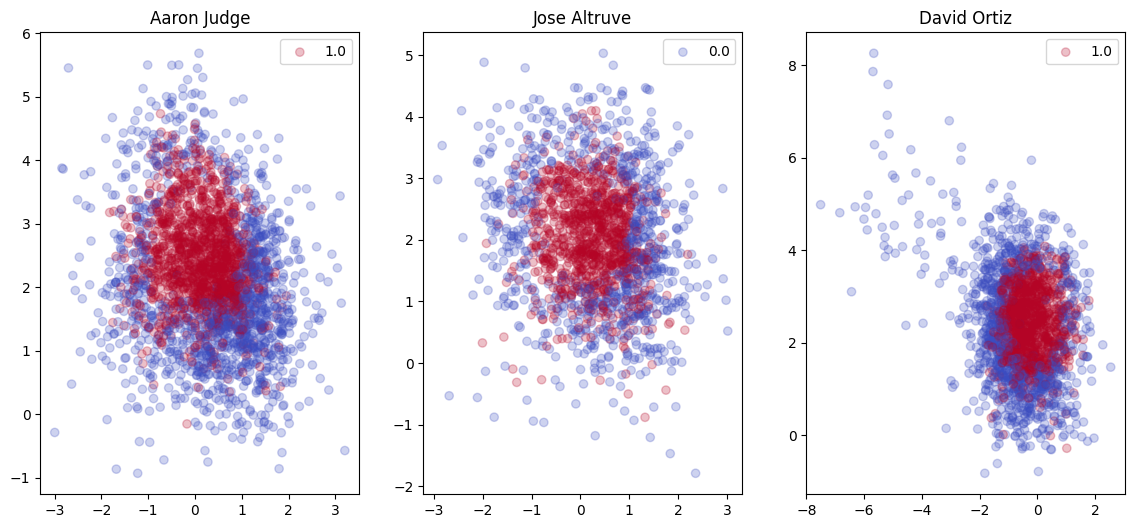

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
axes[0].set_title("Aaron Judge")
axes[1].set_title("Jose Altruve")
axes[2].set_title("David Ortiz")
axes[0].scatter(x = aaron_judge.plate_x, y = aaron_judge.plate_z, c = aaron_judge.type, cmap = plt.cm.coolwarm, alpha = .25)
axes[0].legend(aaron_judge.type)
axes[1].scatter(x = jose_altruve.plate_x, y = jose_altruve.plate_z, c = jose_altruve.type, cmap = plt.cm.coolwarm, alpha = .25)
axes[1].legend(jose_altruve.type)
axes[2].scatter(x = david_ortiz.plate_x, y = david_ortiz.plate_z, c = david_ortiz.type, cmap = plt.cm.coolwarm, alpha = .25)
axes[2].legend(david_ortiz.type)
plt.show()

# Building the SVM

<p style="font-size: 20px;"><b>Task 9</b></p>  
Now that we’ve seen the location of every pitch, let’s create an SVM to create a decision boundary. This decision boundary will be the real strike zone for that player. For this section, make sure to write all of your code below the call to the scatter function but above the show function.

To begin, we want to validate our model, so we need to split the data into a training set and a validation set.

Call the train_test_split function using aaron_judge as a parameter.

Set the parameter random_state equal to 1 to ensure your data is split in the same way as our solution code.

This function returns two objects. Store the return values in variables named training_set and validation_set.

In [12]:
training_set, validation_set = train_test_split(aaron_judge, random_state = 1)

<p style="font-size: 20px;"><b>Task 10</b></p>  
Next, create an SVC named classifier with kernel = 'rbf'. For right now, don’t worry about setting the C or gamma parameters.

In [13]:
classifier = SVC(kernel="rbf")

<p style="font-size: 20px;"><b>Task 11</b></p>  
Call classifier‘s .fit() method. This method should take two parameters:

The training data. This is the plate_x column and the plate_z column in training_set.
The labels. This is the type column in training_set.

In [14]:
x_train = training_set[["plate_x", "plate_z"]]
y_train = training_set["type"]
classifier.fit(x_train, y_train)

SVC()

12.
To visualize the SVM, call the draw_boundary function. This is a function that we wrote ourselves - you won’t find it in scikit-learn.

This function takes two parameters:

The axes of your graph. For us, this is the ax variable that we defined at the top of your code.
The trained SVM. For us, this is classifier. Make sure you’ve called .fit() before trying to visualize the decision boundary.
Run your code to see the predicted strike zone!

Note that the decision boundary will be drawn based on the size of the current axes. So if you call draw_boundary before calling scatter function, you will only see the boundary as a small square.

To get around this, you could manually set the size of the axes by using something like ax.set_ylim(-2, 2) before calling draw_boundary.

/home/alamanna1/.pyenv/versions/3.10.6/envs/lewagon/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


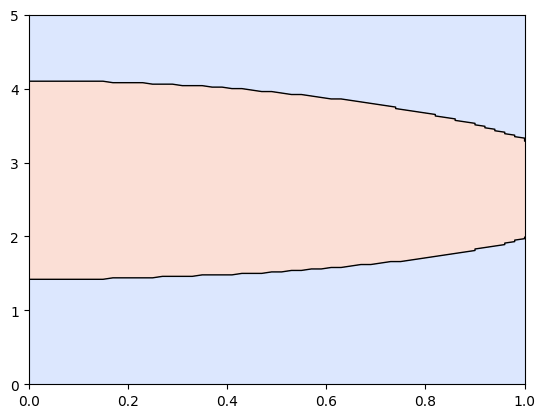

In [15]:
fig, ax = plt.subplots()
ax.set_ylim(0, 5)
ax.set_xlim(0, 1)
draw_boundary(ax, classifier)

# Optimizing the SVM

<p style="font-size: 20px;"><b>Task 13</b></p>  
Nice work! We’re now able to see the strike zone. But we don’t know how accurate our classifier is yet. Let’s find its accuracy by calling the .score() method and printing the results.

.score() takes two parameters — the points in the validation set and the labels associated with those points.

These two parameters should be very similar to the parameters used in .fit().


In [16]:
x_val = validation_set[["plate_x", "plate_z"]]
y_val = validation_set["type"]
classifier.score(x_val, y_val)

0.8295625942684767

<p style="font-size: 20px;"><b>Task 14</b></p>  
Let’s change some of the SVM’s parameters to see if we can get better accuracy.

Set the parameters of the SVM to be gamma = 100 and C = 100.

This will overfit the data, but it will be a good place to start. Run the code to see the overfitted decision boundary. What’s the new accuracy?


In [17]:
classifier = SVC(kernel="rbf", gamma = 100, C = 100)

classifier.fit(x_train, y_train)

classifier.score(x_val, y_val)

0.7933634992458521

/home/alamanna1/.pyenv/versions/3.10.6/envs/lewagon/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


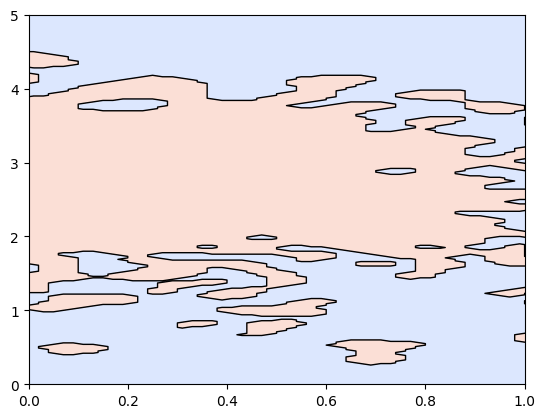

In [18]:
fig, ax = plt.subplots()
ax.set_ylim(0, 5)
ax.set_xlim(0, 1)
draw_boundary(ax, classifier)

<p style="font-size: 20px;"><b>Task 15</b></p>  
Try to find a configuration of gamma and C that greatly improves the accuracy. You may want to use nested for loops.

Loop through different values of gamma and C and print the accuracy using those parameters. Our best SVM had an accuracy of 83.41%. Can you beat ours?


In [19]:
scm_score = 0
gamma_value = 0
c_value = 0
for i in range(1, 20):
    for j in range (1, 20):
        classifier = SVC(kernel="rbf", gamma = i, C = j)
        classifier.fit(x_train, y_train)
        score = classifier.score(x_val, y_val)
        if score > scm_score:
            scm_score = score
            gamma_value = i
            c_value = j

In [21]:
print(f"Best accuracy: {scm_score:.4f} with gamma={gamma_value} and C={c_value}")

Best accuracy: 0.8356 with gamma=1 and C=12


<p style="font-size: 20px;"><b>Task 16</b></p>  
Finally, let’s see how different players’ strike zones change. Aaron Judge is the tallest player in the MLB. Jose Altuve is the shortest player. Instead of using the aaron_judge variable, use jose_altuve.

To make this easier, you might want to consider putting all of your code inside a function and using the dataset as a parameter.

We’ve also imported david_ortiz.

Note that the range of the axes will change for these players. To really compare the strike zones, you may want to force the axes to be the same.

Try putting ax.set_ylim(-2, 6) and ax.set_xlim(-3, 3) right before calling plt.show()


Jose Altuve → Best accuracy: 0.8326 with gamma=2 and C=7


/home/alamanna1/.pyenv/versions/3.10.6/envs/lewagon/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


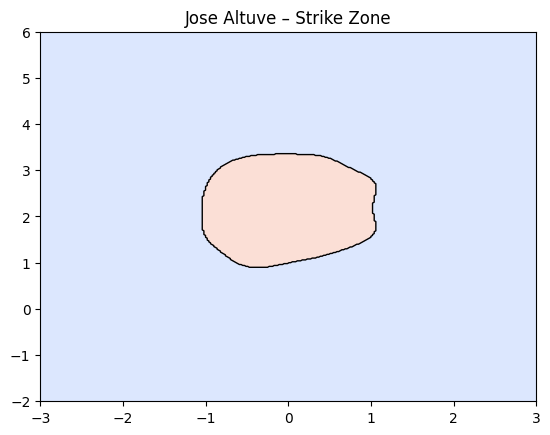

In [23]:
# ----------------------------
# JOSE ALTUVE
# ----------------------------
training_set, validation_set = train_test_split(jose_altruve, random_state=1)
x_train = training_set[["plate_x", "plate_z"]]
y_train = training_set["type"]
x_val = validation_set[["plate_x", "plate_z"]]
y_val = validation_set["type"]

scm_score = 0
gamma_value = 0
c_value = 0

for i in range(1, 20):
    for j in range(1, 20):
        classifier = SVC(kernel="rbf", gamma=i, C=j)
        classifier.fit(x_train, y_train)
        score = classifier.score(x_val, y_val)
        if score > scm_score:
            scm_score = score
            gamma_value = i
            c_value = j

print(f"Jose Altuve → Best accuracy: {scm_score:.4f} with gamma={gamma_value} and C={c_value}")

classifier = SVC(kernel="rbf", gamma=gamma_value, C=c_value)
classifier.fit(x_train, y_train)

fig, ax = plt.subplots()
ax.set_ylim(-2, 6)
ax.set_xlim(-3, 3)
ax.set_title("Jose Altuve – Strike Zone")
draw_boundary(ax, classifier)
plt.show()

In [ ]:
# ----------------------------
# DAVID ORTIZ
# ----------------------------
training_set, validation_set = train_test_split(david_ortiz, random_state=1)
x_train = training_set[["plate_x", "plate_z"]]
y_train = training_set["type"]
x_val = validation_set[["plate_x", "plate_z"]]
y_val = validation_set["type"]

scm_score = 0
gamma_value = 0
c_value = 0

for i in range(1, 20):
    for j in range(1, 20):
        classifier = SVC(kernel="rbf", gamma=i, C=j)
        classifier.fit(x_train, y_train)
        score = classifier.score(x_val, y_val)
        if score > scm_score:
            scm_score = score
            gamma_value = i
            c_value = j

print(f"David Ortiz → Best accuracy: {scm_score:.4f} with gamma={gamma_value} and C={c_value}")

classifier = SVC(kernel="rbf", gamma=gamma_value, C=c_value)
classifier.fit(x_train, y_train)

fig, ax = plt.subplots()
ax.set_ylim(-2, 6)
ax.set_xlim(-3, 3)
ax.set_title("David Ortiz – Strike Zone")
draw_boundary(ax, classifier)
plt.show()